In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
store_df = pd.read_csv("D:/projects/Final Project/SmartRetail Insights/data/store.csv")
train_df = pd.read_csv("D:/projects/Final Project/SmartRetail Insights/data/train.csv", parse_dates=['Date'])


C:\Users\cw\AppData\Local\Temp\ipykernel_21312\961982518.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("D:/projects/Final Project/SmartRetail Insights/data/train.csv", parse_dates=['Date'])


In [4]:
df = pd.merge(train_df, store_df, on='Store', how='left')

In [5]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Mon, 6=Sun
df['IsWeekend'] = df['DayOfWeek'].isin([5,6]).astype(int)


In [7]:
categorical_cols = ['StoreType', 'Assortment','PromoInterval']
df[categorical_cols] = df[categorical_cols].fillna('None')
df = pd.get_dummies(df, columns=categorical_cols)


In [8]:
df = df[(df['Open'] == 1) & (df['Sales'] > 0)]

In [9]:
# X = df.drop(['Sales', 'Customers', 'Date'], axis=1)
# y = df['Sales']

In [10]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
pip install lightgbm

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.




[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'Day',
       'WeekOfYear', 'IsWeekend', 'StoreType_a', 'StoreType_b', 'StoreType_c',
       'StoreType_d', 'Assortment_a', 'Assortment_b', 'Assortment_c',
       'PromoInterval_Feb,May,Aug,Nov', 'PromoInterval_Jan,Apr,Jul,Oct',
       'PromoInterval_Mar,Jun,Sept,Dec', 'PromoInterval_None'],
      dtype='object')

In [13]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,CompetitionDistance,...,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",PromoInterval_None
0,1,4,2015-07-31,5263,555,1,1,0,1,1270.0,...,False,True,False,True,False,False,False,False,False,True
1,2,4,2015-07-31,6064,625,1,1,0,1,570.0,...,False,False,False,True,False,False,False,True,False,False
2,3,4,2015-07-31,8314,821,1,1,0,1,14130.0,...,False,False,False,True,False,False,False,True,False,False
3,4,4,2015-07-31,13995,1498,1,1,0,1,620.0,...,False,True,False,False,False,True,False,False,False,True
4,5,4,2015-07-31,4822,559,1,1,0,1,29910.0,...,False,False,False,True,False,False,False,False,False,True


In [14]:
df.dtypes

Store                                      int64
DayOfWeek                                  int32
Date                              datetime64[ns]
Sales                                      int64
Customers                                  int64
Open                                       int64
Promo                                      int64
StateHoliday                              object
SchoolHoliday                              int64
CompetitionDistance                      float64
CompetitionOpenSinceMonth                float64
CompetitionOpenSinceYear                 float64
Promo2                                     int64
Promo2SinceWeek                          float64
Promo2SinceYear                          float64
Year                                       int32
Month                                      int32
Day                                        int32
WeekOfYear                                UInt32
IsWeekend                                  int64
StoreType_a         

In [15]:
# Drop raw categorical cols after one-hot encoding
df = df.drop(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'], axis=1, errors='ignore')

# Confirm only numeric types
print(df.dtypes[df.dtypes == 'object'])

# Train-test split (repeat if necessary)
X = df.drop(['Sales', 'Date', 'Customers'], axis=1, errors='ignore')
y = df['Sales']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Series([], dtype: object)


In [16]:
# from lightgbm import LGBMRegressor
# from sklearn.metrics import mean_squared_error

# # Rename columns to remove unsupported characters
# X_train.columns = X_train.columns.str.replace(r"[^\w]", "_", regex=True)
# X_test.columns = X_test.columns.str.replace(r"[^\w]", "_", regex=True)

# model = LGBMRegressor()
# model.fit(X_train, y_train)

# preds = model.predict(X_test)
# rmse = mean_squared_error(y_test, preds, squared=False)
# print(f"RMSE: {rmse}")

In [ ]:
import joblib
joblib.dump(model, "D:/projects/Final Project/SmartRetail Insights/backend/models/sales_forecast_model.pkl")

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
preds = model.predict(X_test)

# Evaluation metrics
print("RMSE:", mean_squared_error(y_test, preds, squared=False))
print("MAE:", mean_absolute_error(y_test, preds))
print("R² Score:", r2_score(y_test, preds))

RMSE: 1687.3442043465689
MAE: 1246.9381341036706
R² Score: 0.7049473105944812


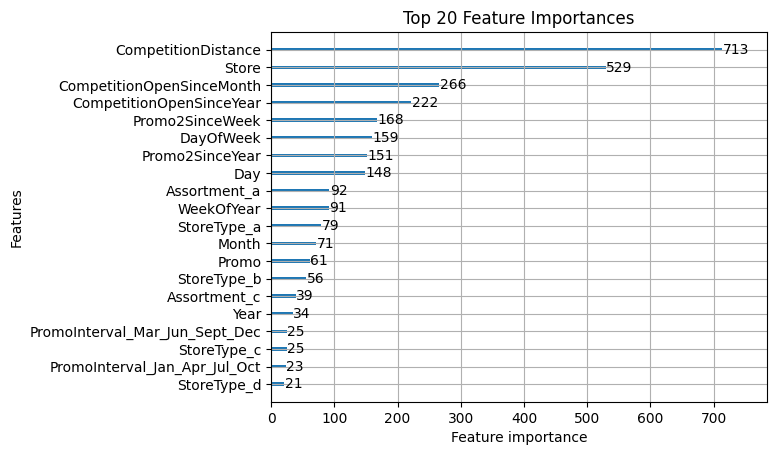

In [ ]:
import matplotlib.pyplot as plt
import lightgbm as lgb

lgb.plot_importance(model, max_num_features=20)
plt.title("Top 20 Feature Importances")
plt.show()


In [19]:
import pandas as pd
import joblib

# Step 1: Load model and features
model = joblib.load("models/sales_forecast_model.pkl")
model_features = model.booster_.feature_name()

# Step 2: Define your sample data
sample_data = pd.DataFrame([{
    'Store': 1,
    'DayOfWeek': 4,
    'Promo': 1,
    'SchoolHoliday': 0,
    'StateHoliday_0': 1,
    'StateHoliday_a': 0,
    'StateHoliday_b': 0,
    'StateHoliday_c': 0,
    'StoreType_a': 1,
    'StoreType_b': 0,
    'StoreType_c': 0,
    'StoreType_d': 0,
    'Assortment_a': 1,
    'Assortment_b': 0,
    'Assortment_c': 0,
    'Promo2': 1,
    'Promo2SinceWeek': 13,
    'Promo2SinceYear': 2011,
    'CompetitionDistance': 150.0,
    'CompetitionOpenSinceMonth': 9,
    'CompetitionOpenSinceYear': 2008,
    'PromoInterval_Feb_May_Aug_Nov': 0,
    'PromoInterval_Jan_Apr_Jul_Oct': 0,
    'PromoInterval_Mar_Jun_Sept_Dec': 0,
    'PromoInterval_None': 1
}])

# Step 3: Add any missing columns with default value 0
for col in model_features:
    if col not in sample_data.columns:
        sample_data[col] = 0

# Step 4: Reorder columns to match training
X = sample_data[model_features]

# Step 5: Predict
prediction = model.predict(X)

# Step 6: Show result
print("Predicted Sales:", prediction[0])

Predicted Sales: 9090.845464725373
